# IMDb Movie Reviews – NLP Classification

<div align='center'>
<img src='https://repository-images.githubusercontent.com/446393339/d4481b17-7960-4f3c-b040-8507df57f81b' width='600'>
</div>

### Introduction

In the era of digital media, understanding user sentiment from textual data has become increasingly important for applications such as recommendation systems, customer feedback analysis, and content moderation.

In this project, we tackle the sentiment classification problem using the Bag of Words Meets Bags of Popcorn dataset, which contains movie reviews labeled as positive or negative. The primary objective is to build a robust model that can accurately classify the sentiment of unseen reviews.

We begin by performing text preprocessing, including lowercasing, removal of punctuation and numerical values, and normalization of whitespace. Additionally, lemmatization is applied to reduce words to their base forms, improving the model’s ability to generalize across similar expressions.

To convert textual data into numerical features, we utilize the TF-IDF (Term Frequency–Inverse Document Frequency) technique. Finally, a Logistic Regression model is trained to perform binary classification on the processed data.

### Importing Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns, re
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

### Read Data

In [2]:
train = pd.read_csv("/kaggle/input/competitions/word2vec-nlp-tutorial/labeledTrainData.tsv.zip", sep="\t", compression="zip")

In [3]:
test = pd.read_csv("/kaggle/input/competitions/word2vec-nlp-tutorial/testData.tsv.zip", sep="\t", compression="zip")

### EDA

In [4]:
train.head()

,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


In [5]:
train.tail()

,id,sentiment,review
24995,3453_3,0,It seems like more consideration has gone into...
24996,5064_1,0,I don't believe they made this film. Completel...
24997,10905_3,0,"Guy is a loser. Can't get girls, needs to buil..."
24998,10194_3,0,This 30 minute documentary Buñuel made in the ...
24999,8478_8,1,I saw this movie as a child and it broke my he...


In [6]:
train.shape

(25000, 3)

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         25000 non-null  object
 1   sentiment  25000 non-null  int64 
 2   review     25000 non-null  object
dtypes: int64(1), object(2)
memory usage: 586.1+ KB


In [8]:
train.isnull().sum()

id           0
sentiment    0
review       0
dtype: int64

In [10]:
test.head()

,id,review
0,12311_10,Naturally in a film who's main themes are of m...
1,8348_2,This movie is a disaster within a disaster fil...
2,5828_4,"All in all, this is a movie for kids. We saw i..."
3,7186_2,Afraid of the Dark left me with the impression...
4,12128_7,A very accurate depiction of small time mob li...


In [11]:
test.tail()

,id,review
24995,2155_10,"Sony Pictures Classics, I'm looking at you! So..."
24996,59_10,I always felt that Ms. Merkerson had never got...
24997,2531_1,I was so disappointed in this movie. I am very...
24998,7772_8,"From the opening sequence, filled with black a..."
24999,11465_10,This is a great horror film for people who don...


In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      25000 non-null  object
 1   review  25000 non-null  object
dtypes: object(2)
memory usage: 390.8+ KB


In [13]:
test.shape

(25000, 2)

In [14]:
test.isnull().sum()

id        0
review    0
dtype: int64

### Data Visualization

In [17]:
train['sentiment'].value_counts()

sentiment
1    12500
0    12500
Name: count, dtype: int64

Text(0.5, 1.0, 'Sentiment Distribution')

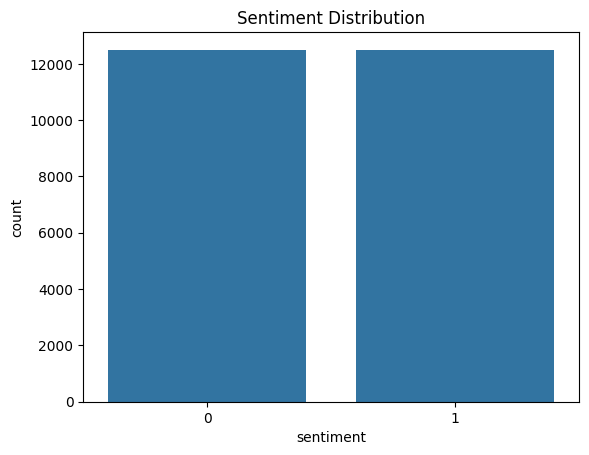

In [15]:
sns.countplot(data=train, x='sentiment')
plt.title("Sentiment Distribution")

In [21]:
train['review_length'] = train['review'].str.len()

Text(0.5, 1.0, 'Review Length Distribution')

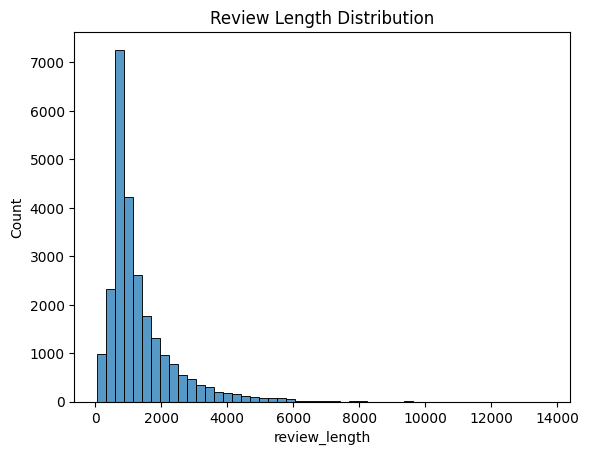

In [22]:
sns.histplot(train['review_length'], bins=50)
plt.title('Review Length Distribution')

In [26]:
train['word_count']=train['review'].apply(lambda x: len(x.split()))
train['word_count'].describe()

count    25000.000000
mean       233.787640
std        173.733321
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: word_count, dtype: float64

<Axes: xlabel='sentiment', ylabel='word_count'>

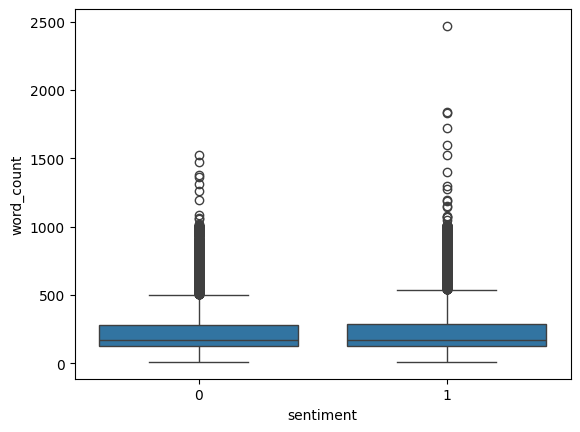

In [28]:
sns.boxplot(x='sentiment', y='word_count', data=train)

In [29]:
from collections import Counter
all_words = " ".join(train['review']).split()
Counter(all_words).most_common(20)

[('the', 287032),
 ('a', 155096),
 ('and', 152664),
 ('of', 142972),
 ('to', 132568),
 ('is', 103228),
 ('in', 85580),
 ('I', 65973),
 ('that', 64560),
 ('this', 57196),
 ('it', 54429),
 ('/><br', 50935),
 ('was', 46698),
 ('as', 42510),
 ('with', 41721),
 ('for', 41070),
 ('but', 33790),
 ('The', 33762),
 ('on', 30766),
 ('movie', 30500)]

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

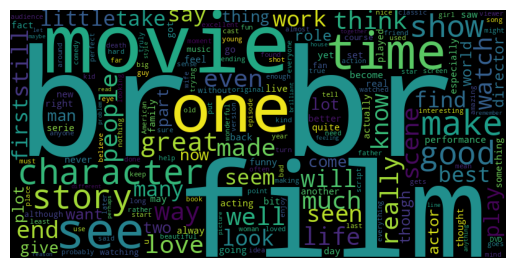

In [31]:
text = " ".join(train[train['sentiment']==1]['review'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

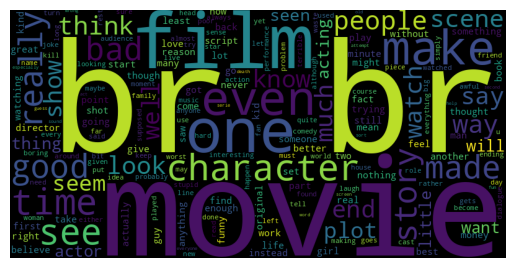

In [32]:
text = " ".join(train[train['sentiment']==0]['review'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")

### Text Cleaning

In [34]:
train['review']=train['review'].str.lower() # kucuk harfe cevir
train['review']=train['review'].str.replace('[^\w\s]','', regex=True) # noktolama isaretlerini kaldirir
train['review']=train['review'].str.replace('\d+','', regex=True) # rakamlari kaldirir
train['review']=train['review'].str.replace('\n','', regex=True) # satir sonlarini kaldirir
train['review']=train['review'].str.replace('\r','', regex=True) # enter lari kaldiri

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_55/3155471418.py:2: SyntaxWarning: invalid escape sequence '\w'
  train['review']=train['review'].str.replace('[^\w\s]','', regex=True) # noktolama isaretlerini kaldirir
/tmp/ipykernel_55/3155471418.py:3: SyntaxWarning: invalid escape sequence '\d'
  train['review']=train['review'].str.replace('\d+','', regex=True) # rakamlari kaldirir


In [44]:
test['review']=test['review'].str.lower() # kucuk harfe cevir
test['review']=test['review'].str.replace('[^\w\s]','', regex=True) # noktolama isaretlerini kaldirir
test['review']=test['review'].str.replace('\d+','', regex=True) # rakamlari kaldirir
test['review']=test['review'].str.replace('\n','', regex=True) # satir sonlarini kaldirir
test['review']=test['review'].str.replace('\r','', regex=True) # enter lari kaldiri

<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_55/653173919.py:2: SyntaxWarning: invalid escape sequence '\w'
  test['review']=test['review'].str.replace('[^\w\s]','', regex=True) # noktolama isaretlerini kaldirir
/tmp/ipykernel_55/653173919.py:3: SyntaxWarning: invalid escape sequence '\d'
  test['review']=test['review'].str.replace('\d+','', regex=True) # rakamlari kaldirir


In [35]:
train['review'][0]

'with all this stuff going down at the moment with mj ive started listening to his music watching the odd documentary here and there watched the wiz and watched moonwalker again maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe make up my mind whether he is guilty or innocent moonwalker is part biography part feature film which i remember going to see at the cinema when it was originally released some of it has subtle messages about mjs feeling towards the press and also the obvious message of drugs are bad mkaybr br visually impressive but of course this is all about michael jackson so unless you remotely like mj in anyway then you are going to hate this and find it boring some may call mj an egotist for consenting to the making of this movie but mj and most of his fans would say that he made it for the fans which if true is really nice of himbr br the actual feature film bit when it finally starts is only on for  minu

In [37]:
from textblob import TextBlob
def ekkok(text):
    words = TextBlob(text).words
    return " ".join([word.lemmatize() for word in words])

In [38]:
train['review'] = train['review'].apply(ekkok)

In [45]:
test['review'] = test['review'].apply(ekkok)

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

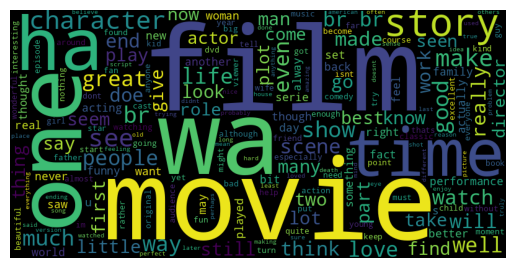

In [39]:
text = " ".join(train[train['sentiment']==1]['review'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

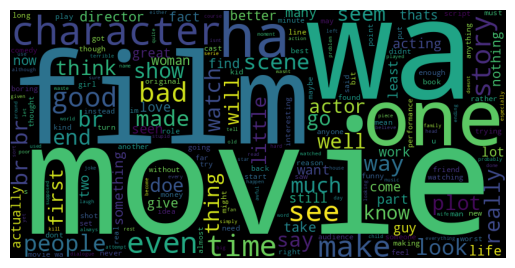

In [40]:
text = " ".join(train[train['sentiment']==0]['review'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")

In [41]:
tfidf = TfidfVectorizer(max_features=20000, stop_words="english", ngram_range=(1,2))

In [42]:
x = tfidf.fit_transform(train["review"])

In [46]:
x_test = tfidf.transform(test["review"])

In [43]:
y = train["sentiment"]

In [47]:
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.2, random_state=42)

In [48]:
model = LogisticRegression(max_iter=300)

In [49]:
model.fit(x_train, y_train)

LogisticRegression(max_iter=300)

In [50]:
pred = model.predict(x_valid)

In [51]:
accuracy_score(y_valid, pred)

0.884

In [52]:
print(classification_report(y_valid, pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      2481
           1       0.87      0.90      0.89      2519

    accuracy                           0.88      5000
   macro avg       0.88      0.88      0.88      5000
weighted avg       0.88      0.88      0.88      5000



Text(50.722222222222214, 0.5, 'Actual')

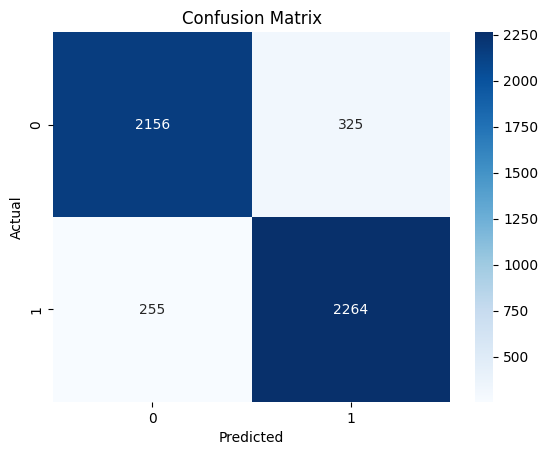

In [53]:
sns.heatmap(confusion_matrix(y_valid, pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [54]:
test_pred = model.predict(x_test)

In [55]:
submission = pd.DataFrame({"id": test["id"], "sentiment": test_pred})

In [56]:
submission.to_csv("submission.csv", index=False)

In [57]:
import joblib
joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

### Conclusion

In this project, we successfully developed a sentiment analysis model capable of classifying movie reviews with an accuracy of approximately 88.4% using Logistic Regression. Despite its simplicity, the model demonstrates strong performance when combined with effective text preprocessing and TF-IDF feature extraction.

One of the key takeaways from this work is that classical machine learning models, when paired with proper feature engineering, can achieve highly competitive results without the need for complex deep learning architectures.

The preprocessing pipeline—including text cleaning and lemmatization—played a crucial role in improving model performance by reducing noise and enhancing semantic consistency. This highlights the importance of data preparation in NLP tasks.

While the current model provides a strong baseline, there are several opportunities for improvement:

Experimenting with advanced models such as Support Vector Machines or ensemble methods
Utilizing word embeddings (Word2Vec, GloVe) or transformer-based models (BERT)
Incorporating n-grams for capturing phrase-level context

Overall, this project demonstrates how a well-structured NLP pipeline combined with a simple yet effective model can deliver reliable sentiment classification results in real-world scenarios.